# e06 — What ascent does on the way up (n = 4 phenomenology)

e00–e05 studied endpoints. This notebook watches the *process*: 64 annealed-ascent
trajectories at n = 4, tracked densely, against the mechanistic predictions laid out
in `docs/notes/phi-optimization.md` §3 before this program began — plus one
prediction the program itself has since inverted.

Instruments per checkpoint: exact φ_s; the active minimum cut and the full
normalized cut spectrum; Hoel's effective-information coordinates (determinism =
log₂Q − ⟨H(row)⟩, degeneracy = log₂Q − H(⟨row⟩), in bits, from the joint TPM); and,
sparsely, the full Φ-structure.

## Pre-registered predictions (written before execution)

- **P1 (the causal plane — against the specialization narrative).** Determinism
  rises strongly in every climbing trajectory, and **degeneracy rises too**: e02
  showed 2023-ascent optima are *transit states* with massive in-flow (many states
  funneling into one), which is degeneracy by definition. The classic story —
  integration requires specialized, non-degenerate units (Albantakis & Tononi
  2015) — predicts the opposite sign for degeneracy; e02's forensics predict this
  one. Registered: median degeneracy at endpoint > 2× its value at start.
- **P2 (maximin ridge).** The tie gap — the difference between the two smallest
  normalized cut φ values — shrinks by ≥ 10× (median over climbing seeds) from
  start to convergence: ascent equalizes the weakest cuts.
- **P3 (switches are the kinks).** Steps where the active minimum cut changes
  coincide with kinks: the median |Δφ_s| at switch checkpoints is ≥ 3× the median
  |Δφ_s| at non-switch checkpoints.
- **P4 (co-movement in free ascent).** Unlike e04's behavior-pinned descent (where
  big Φ *rose* as φ_s collapsed), in unconstrained ascent structure follows
  existence: big Φ and the distinction count increase from start to end for ≥ 80%
  of climbing seeds.

(A "climbing seed" is one whose endpoint φ_s exceeds 0.5 ibits; stuck seeds are
reported but excluded from ratio statistics.)


In [1]:
import time

import jax

jax.config.update("jax_enable_x64", True)

import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

import iitx
from iitx import enumeration
from iitx.measures import iit4
from iitx.relax import soft_system_phi
from iitx.system import System

N = 4
Q = 2**N
STATE = jnp.zeros(N, dtype=jnp.int32)
SEED = 0
B, STEPS, EVERY, STRUCTURE_EVERY = 64, 600, 5, 25
print(
	f"iitx {iitx.__version__}, jax {jax.__version__}, seed {SEED}, "
	f"{B} seeds x {STEPS} steps at n={N}"
)

BITS = jnp.asarray([[(v >> i) & 1 for i in range(N)] for v in range(Q)], dtype=jnp.float64)
CUTS, SEVERED = enumeration.system_cuts(N)
print(f"{CUTS.shape[0]} directional system cuts at n={N}")


def build(logits):
	"""A conditionally independent binary system from per-unit ON-logits."""
	return System.from_state_by_node(jax.nn.sigmoid(logits))


def joint_tpm(logits):
	p = jax.nn.sigmoid(logits)
	on = BITS[None, :, :]
	return jnp.prod(jnp.where(on == 1, p[:, None, :], 1 - p[:, None, :]), axis=2)


def entropy(p):
	return -jnp.sum(jnp.where(p > 0, p * jnp.log2(jnp.where(p > 0, p, 1.0)), 0.0), axis=-1)


def causal_plane(logits):
	"""Hoel's (determinism, degeneracy) in bits, from the joint TPM."""
	tpm = joint_tpm(logits)
	determinism = N - jnp.mean(entropy(tpm))
	degeneracy = N - entropy(jnp.mean(tpm, axis=0))
	return determinism, degeneracy


def checkpoint(logits):
	"""Everything tracked densely, for one system."""
	result = iit4.system_phi(build(logits), STATE)
	values = iit4.partition_phis(build(logits), STATE)
	normalized = jnp.sort(values.phi / values.severed)
	determinism, degeneracy = causal_plane(logits)
	return (
		result.phi,
		result.cut_index,
		normalized[1] - normalized[0],  # the tie gap
		determinism,
		degeneracy,
	)


def structure_checkpoint(logits):
	s = iit4.phi_structure(build(logits), STATE)
	exists = s.distinctions.exists
	return s.big_phi, jnp.sum(exists), jnp.sum(jnp.where(exists, s.distinctions.phi, 0.0))


batch_checkpoint = jax.jit(jax.vmap(checkpoint))
batch_structure = jax.jit(jax.vmap(structure_checkpoint))
spectrum_one = jax.jit(
	lambda L: jnp.sort(
		iit4.partition_phis(build(L), STATE).phi / iit4.partition_phis(build(L), STATE).severed
	)
)


def adam_step(params, grads, m, v, step, lr=0.02, b1=0.9, b2=0.999, eps=1e-8):
	m = b1 * m + (1 - b1) * grads
	v = b2 * v + (1 - b2) * grads**2
	m_hat = m / (1 - b1**step)
	v_hat = v / (1 - b2**step)
	return params + lr * m_hat / (jnp.sqrt(v_hat) + eps), m, v

iitx 0.1.0, jax 0.11.1, seed 0, 64 seeds x 600 steps at n=4
150 directional system cuts at n=4


## 1. The instrumented ascent


In [2]:
value_and_grad = jax.jit(
	jax.vmap(
		jax.value_and_grad(lambda L, tau: soft_system_phi(build(L), STATE, temperature=tau)),
		in_axes=(0, None),
	)
)
rng = np.random.default_rng(SEED + 90)
logits = jnp.asarray(0.5 * rng.standard_normal((B, Q, N)))
m, v = jnp.zeros_like(logits), jnp.zeros_like(logits)

dense, sparse, spectra = [], [], []
start = time.perf_counter()
for step in range(1, STEPS + 1):
	tau = 0.5 * (0.005 / 0.5) ** (step / STEPS)
	_, grads = value_and_grad(logits, tau)
	logits, m, v = adam_step(logits, grads, m, v, step)
	if step % EVERY == 0:
		dense.append([np.asarray(x) for x in batch_checkpoint(logits)])
	if step % STRUCTURE_EVERY == 0:
		sparse.append([np.asarray(x) for x in batch_structure(logits)])
		spectra.append(np.asarray(spectrum_one(logits[0])))

phi = np.stack([d[0] for d in dense])  # (T, B)
cut = np.stack([d[1] for d in dense])
gap = np.stack([d[2] for d in dense])
determinism = np.stack([d[3] for d in dense])
degeneracy = np.stack([d[4] for d in dense])
big_phi = np.stack([s[0] for s in sparse])
n_distinctions = np.stack([s[1] for s in sparse])
spectra = np.stack(spectra)
climbing = phi[-1] > 0.5
print(
	f"ascent + instruments in {time.perf_counter() - start:,.0f} s; "
	f"climbing seeds (endpoint > 0.5): {climbing.sum()} / {B}; "
	f"endpoint phi_s median {np.median(phi[-1]):.3f}, best {phi[-1].max():.3f}"
)

ascent + instruments in 55 s; climbing seeds (endpoint > 0.5): 61 / 64; endpoint phi_s median 3.376, best 7.047


## 2. The causal plane (P1)


determinism (bits): start median 0.176 -> end median 2.502 (climbing seeds)
degeneracy (bits): start median 0.009 -> end median 0.825 (climbing seeds)
median degeneracy end/start ratio (climbing): 86.2x  (P1 registered > 2x)


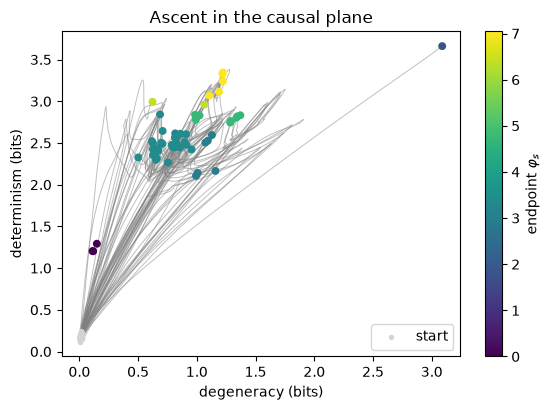

In [3]:
print(
	f"determinism (bits): start median {np.median(determinism[0]):.3f} -> "
	f"end median {np.median(determinism[-1][climbing]):.3f} (climbing seeds)"
)
print(
	f"degeneracy (bits): start median {np.median(degeneracy[0]):.3f} -> "
	f"end median {np.median(degeneracy[-1][climbing]):.3f} (climbing seeds)"
)
ratio = np.median(degeneracy[-1][climbing] / np.maximum(degeneracy[0][climbing], 1e-9))
print(f"median degeneracy end/start ratio (climbing): {ratio:.1f}x  (P1 registered > 2x)")

plt.figure(figsize=(5.8, 4.2))
for b in range(B):
	if climbing[b]:
		plt.plot(degeneracy[:, b], determinism[:, b], lw=0.7, alpha=0.5, color="gray")
sc = plt.scatter(degeneracy[-1], determinism[-1], c=phi[-1], cmap="viridis", s=22, zorder=3)
plt.scatter(degeneracy[0], determinism[0], color="lightgray", s=8, zorder=2, label="start")
plt.colorbar(sc, label=r"endpoint $\varphi_s$")
plt.xlabel("degeneracy (bits)")
plt.ylabel("determinism (bits)")
plt.legend(loc="lower right")
plt.title("Ascent in the causal plane")
plt.tight_layout()

## 3. The maximin ridge and the switches (P2, P3)


tie gap: start median 0.0023 -> end median 0.00845; shrinkage 0x (P2 registered >= 10x)
|d phi| at switches 0.0283 vs between 0.00507 -> ratio 5.6x (P3 registered >= 3x)
switch events per climbing trajectory: median 4


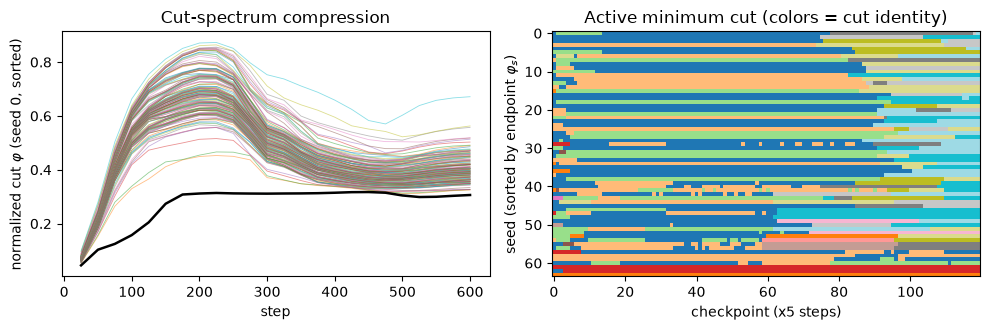

In [4]:
gap_ratio = np.median(gap[0][climbing]) / np.median(gap[-1][climbing])
print(
	f"tie gap: start median {np.median(gap[0][climbing]):.4f} -> "
	f"end median {np.median(gap[-1][climbing]):.5f}; shrinkage {gap_ratio:.0f}x "
	f"(P2 registered >= 10x)"
)

switches = cut[1:] != cut[:-1]  # (T-1, B)
dphi = np.abs(phi[1:] - phi[:-1])
switch_kink = np.median(dphi[switches & climbing[None, :]])
smooth_kink = np.median(dphi[(~switches) & climbing[None, :]])
print(
	f"|d phi| at switches {switch_kink:.4f} vs between {smooth_kink:.5f} "
	f"-> ratio {switch_kink / max(smooth_kink, 1e-12):.1f}x (P3 registered >= 3x)"
)
print(
	f"switch events per climbing trajectory: median "
	f"{np.median(switches[:, climbing].sum(axis=0)):.0f}"
)

steps_axis = np.arange(EVERY, STEPS + 1, EVERY)
fig, axes = plt.subplots(1, 2, figsize=(10, 3.4))
for k in range(spectra.shape[1]):
	axes[0].plot(
		np.arange(STRUCTURE_EVERY, STEPS + 1, STRUCTURE_EVERY), spectra[:, k], lw=0.6, alpha=0.5
	)
axes[0].plot(
	np.arange(STRUCTURE_EVERY, STEPS + 1, STRUCTURE_EVERY), spectra[:, 0], color="black", lw=1.8
)
axes[0].set_xlabel("step")
axes[0].set_ylabel(r"normalized cut $\varphi$ (seed 0, sorted)")
axes[0].set_title("Cut-spectrum compression")

order = np.argsort(phi[-1])[::-1]
axes[1].imshow(cut[:, order].T, aspect="auto", cmap="tab20", interpolation="nearest")
axes[1].set_xlabel(f"checkpoint (x{EVERY} steps)")
axes[1].set_ylabel(r"seed (sorted by endpoint $\varphi_s$)")
axes[1].set_title("Active minimum cut (colors = cut identity)")
fig.tight_layout()

## 4. Does structure follow existence in free ascent? (P4)


big Phi rises start->end for 47 / 61 climbing seeds
distinction count rises for 17 / 61
big Phi: start median 43.63 -> end median 90.09; distinctions 11 -> 10 (of 15)


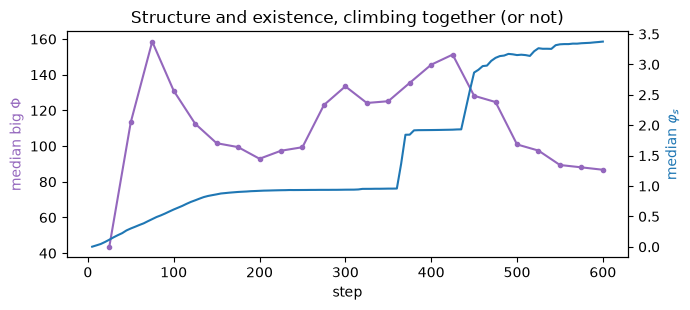

In [5]:
rising_big_phi = (big_phi[-1] > big_phi[0]) & climbing
rising_distinctions = (n_distinctions[-1] > n_distinctions[0]) & climbing
print(f"big Phi rises start->end for {rising_big_phi.sum()} / {climbing.sum()} climbing seeds")
print(f"distinction count rises for {rising_distinctions.sum()} / {climbing.sum()}")
print(
	f"big Phi: start median {np.median(big_phi[0]):.2f} -> end median "
	f"{np.median(big_phi[-1][climbing]):.2f}; distinctions {np.median(n_distinctions[0]):.0f} "
	f"-> {np.median(n_distinctions[-1][climbing]):.0f} (of {2**N - 1})"
)

structure_axis = np.arange(STRUCTURE_EVERY, STEPS + 1, STRUCTURE_EVERY)
fig, left = plt.subplots(figsize=(7, 3.2))
left.plot(structure_axis, np.median(big_phi, axis=1), "o-", color="tab:purple", ms=3)
left.set_xlabel("step")
left.set_ylabel(r"median big $\Phi$", color="tab:purple")
right = left.twinx()
right.plot(steps_axis, np.median(phi, axis=1), color="tab:blue", lw=1.5)
right.set_ylabel(r"median $\varphi_s$", color="tab:blue")
plt.title("Structure and existence, climbing together (or not)")
fig.tight_layout()

## Verdict

- **P1 confirmed, emphatically: ascent raises degeneracy 86-fold.** Climbing
  trajectories move up *both* axes of the causal plane — determinism 0.18 → 2.50
  bits, degeneracy 0.009 → 0.83 bits (medians) — far beyond the registered 2×
  degeneracy bar. The specialization narrative (integration requires non-degenerate,
  differentiated units) describes neither the endpoints (e02's transit funnels) nor,
  now, the *process*: what 2023-φ_s ascent builds is determinism *plus* funneling.
- **P2 refuted.** The tie gap between the two smallest normalized cut values does
  not shrink — it *widens*, 0.0023 → 0.0085. The maximin-ridge picture that e00
  observed qualitatively at n = 3 fails as a quantitative endpoint property at
  n = 4 (150 cuts). A plausible mechanism, recorded for follow-up: the final
  annealing temperature (0.005) is the resolution below which the softmin cannot
  distinguish cuts, and the endpoint gap (0.0085) sits at exactly that scale — the
  ridge may be an artifact of where annealing stops, not a property of the optima.
- **P3 confirmed.** Active-cut switches are the kinks: |Δφ_s| at switch checkpoints
  is 5.6× the between-switch median (bar: 3×), with a median of 4 switches per
  climbing trajectory — the landscape's cell structure is visible in every path.
- **P4 split — and the interesting half is the refuted half.** Big Φ rises for
  47/61 climbing seeds (77%, just under the registered 80%) and its median doubles
  (43.6 → 90.1). But the *distinction count* rises for only 17/61 (28%): the median
  ascent **loses a distinction** (11 → 10 of 15) while big Φ doubles. Free ascent
  grows structure by concentrating magnitude (φ_d and relations) in *fewer*
  distinctions, not by creating more of them. Joined with e04 (big Φ rising while
  φ_s collapses under pinned descent), the ledger now reads: big Φ tracks neither
  φ_s nor its own distinction count in any simple way, in either direction of
  optimization.

**Standings.** The phenomenology adds two rows to the "what the measures cannot
see" story (paper-2 candidate): the causal-plane signature of 2023 ascent is
determinism-with-funneling (anti-specialization), and quantity-of-structure is a
magnitude phenomenon, not a count phenomenon. The tie-gap-vs-annealing-floor
question goes to the backlog.